In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
X = df.drop(columns='Performance Index')
y = df['Performance Index']

In [4]:
num_cols = X.select_dtypes(include='number').columns
obj_cols = X.select_dtypes(include='object').columns

C:\Users\shail\AppData\Local\Temp\ipykernel_6020\2146109923.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X.select_dtypes(include='object').columns


<Axes: >

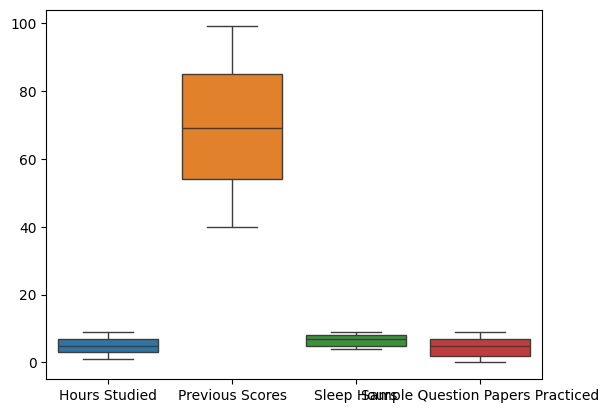

In [5]:
sns.boxplot(X[num_cols])

In [6]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=42)

In [7]:
scaling = MinMaxScaler()
xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
xtrain

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,0.500,0.152542,No,0.6,0.555556
1561,0.125,0.135593,Yes,0.6,0.666667
1670,0.125,0.694915,No,0.6,0.222222
6087,0.125,0.101695,No,0.4,0.111111
6669,0.875,0.118644,No,1.0,0.000000
...,...,...,...,...,...
5734,0.875,0.169492,Yes,0.4,0.666667
5191,0.375,0.474576,No,1.0,0.333333
5390,1.000,0.135593,No,0.6,0.666667
860,0.000,0.118644,No,1.0,0.000000


In [8]:
df.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


In [9]:
xtrain[obj_cols].nunique()

Extracurricular Activities    2
dtype: int64

In [10]:
obj_cols

Index(['Extracurricular Activities'], dtype='str')

In [11]:
xtrain[obj_cols]

,Extracurricular Activities
9254,No
1561,Yes
1670,No
6087,No
6669,No
...,...
5734,Yes
5191,No
5390,No
860,No


In [12]:
# label_encoder = LabelEncoder()
# xtrain['Extracurricular Activities'] = label_encoder.fit_transform(xtrain['Extracurricular Activities'])
# xtrain

In [13]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
values = encoder.fit_transform(xtrain[obj_cols])
cols = encoder.get_feature_names_out()

In [14]:
xtrain[cols] = values
xtrain.drop(columns=['Extracurricular Activities'],inplace=True)
xtrain

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,0.500,0.152542,0.6,0.555556,1.0,0.0
1561,0.125,0.135593,0.6,0.666667,0.0,1.0
1670,0.125,0.694915,0.6,0.222222,1.0,0.0
6087,0.125,0.101695,0.4,0.111111,1.0,0.0
6669,0.875,0.118644,1.0,0.000000,1.0,0.0
...,...,...,...,...,...,...
5734,0.875,0.169492,0.4,0.666667,0.0,1.0
5191,0.375,0.474576,1.0,0.333333,1.0,0.0
5390,1.000,0.135593,0.6,0.666667,1.0,0.0
860,0.000,0.118644,1.0,0.000000,1.0,0.0


In [15]:
xtest[num_cols] = scaling.transform(xtest[num_cols])
xtest_values = encoder.transform(xtest[obj_cols])
xtest[cols] = xtest_values
xtest.drop(columns=['Extracurricular Activities'],inplace=True)
xtest

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
6252,0.500,0.491525,0.8,0.222222,1.0,0.0
4684,0.125,0.101695,0.0,0.888889,0.0,1.0
1731,0.750,0.271186,0.6,0.555556,0.0,1.0
4742,0.625,0.033898,0.8,0.555556,0.0,1.0
4521,0.750,0.220339,0.0,0.666667,1.0,0.0
...,...,...,...,...,...,...
6412,0.125,0.508475,0.6,0.333333,1.0,0.0
8285,0.375,0.661017,1.0,0.333333,1.0,0.0
7853,0.125,0.000000,0.6,0.222222,0.0,1.0
1095,0.250,0.728814,0.6,0.555556,1.0,0.0


In [16]:
model = LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
#Evaluation
model.score(xtrain,ytrain)

0.9886898790682355

In [18]:
model.score(xtest,ytest)

0.9889832909573145

### The model is goodfit


# Encoding prac data

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [20]:
df=pd.read_csv("encoding_pracdata.csv")

In [21]:
df.head()

,Student_ID,Gender,Age,Major,Attendance_Pct,Study_Hours_Per_Day,Previous_CGPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
0,ID00001,Male,20,Engineering,83.9,4.4,2.65,9.1,8,2.78
1,ID00002,Female,24,Business,80.7,4.0,3.58,4.0,4,3.76
2,ID00003,Female,20,Mathematics,91.5,3.9,3.29,6.7,4,3.75
3,ID00004,Female,23,Engineering,73.9,8.8,3.48,4.0,6,3.69
4,ID00005,Male,21,Economics,79.8,2.2,2.66,8.7,6,2.34


In [22]:
X=df.drop(columns=['Final_CGPA','Student_ID'])
y=df['Final_CGPA']

In [23]:
num_cols = X.select_dtypes(include='number').columns
obj_cols = X.select_dtypes(include='object').columns

C:\Users\shail\AppData\Local\Temp\ipykernel_6020\2146109923.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X.select_dtypes(include='object').columns


<Axes: >

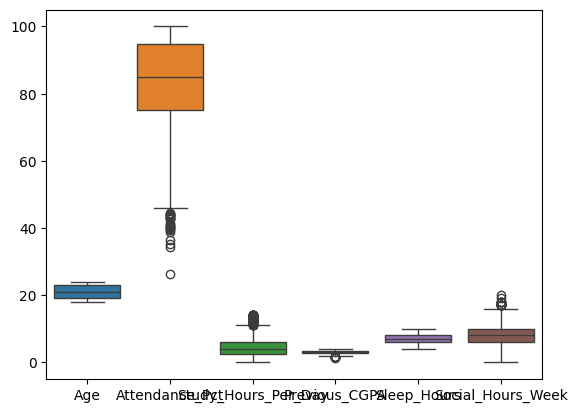

In [24]:
sns.boxplot(X[num_cols])

In [25]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [26]:
scaling=MinMaxScaler()
xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
xtrain

,Gender,Age,Major,Attendance_Pct,Study_Hours_Per_Day,Previous_CGPA,Sleep_Hours,Social_Hours_Week
4227,Female,1.000000,Business,0.685637,0.366906,0.207547,0.566667,0.55
4676,Male,1.000000,Mathematics,1.000000,0.086331,0.577358,0.300000,0.15
800,Female,1.000000,Business,0.850949,0.381295,0.645283,0.516667,0.25
3671,Male,0.666667,Engineering,0.967480,0.431655,0.486792,0.633333,0.45
4193,Female,0.833333,Mathematics,0.970190,0.258993,0.841509,0.600000,0.50
...,...,...,...,...,...,...,...,...
4426,Male,0.666667,Engineering,0.757453,0.129496,0.716981,0.666667,0.05
466,Male,0.666667,Psychology,0.841463,0.086331,0.879245,0.250000,0.70
3092,Male,1.000000,Mathematics,0.720867,0.410072,0.554717,0.483333,0.65
3772,Male,0.000000,Engineering,0.811653,0.079137,0.528302,0.566667,0.55


In [27]:
df.corr(numeric_only=True)

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_CGPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
Age,1.000000,0.023755,0.010266,-0.024369,0.003738,0.003921,-0.012245
Attendance_Pct,0.023755,1.000000,0.022700,0.024346,-0.017246,0.011411,0.302840
Study_Hours_Per_Day,0.010266,0.022700,1.000000,-0.003302,-0.021983,0.002351,0.230898
Previous_CGPA,-0.024369,0.024346,-0.003302,1.000000,0.012845,0.012686,0.878879
Sleep_Hours,0.003738,-0.017246,-0.021983,0.012845,1.000000,0.006848,0.002617
Social_Hours_Week,0.003921,0.011411,0.002351,0.012686,0.006848,1.000000,-0.004927
Final_CGPA,-0.012245,0.302840,0.230898,0.878879,0.002617,-0.004927,1.000000


In [28]:
xtrain[obj_cols].nunique()

Gender    2
Major     6
dtype: int64

In [29]:
obj_cols

Index(['Gender', 'Major'], dtype='str')

In [30]:
xtrain[obj_cols]

,Gender,Major
4227,Female,Business
4676,Male,Mathematics
800,Female,Business
3671,Male,Engineering
4193,Female,Mathematics
...,...,...
4426,Male,Engineering
466,Male,Psychology
3092,Male,Mathematics
3772,Male,Engineering


In [31]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

In [32]:
values=encoder.fit_transform(xtrain[obj_cols])

In [33]:
cols=encoder.get_feature_names_out()

In [34]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

values = encoder.fit_transform(xtrain[obj_cols])

cols = encoder.get_feature_names_out(obj_cols)

xtrain[cols] = values

xtrain.drop(columns=obj_cols, inplace=True)
xtrain

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_CGPA,Sleep_Hours,Social_Hours_Week,Gender_Female,Gender_Male,Major_Business,Major_Computer Science,Major_Economics,Major_Engineering,Major_Mathematics,Major_Psychology
4227,1.000000,0.685637,0.366906,0.207547,0.566667,0.55,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4676,1.000000,1.000000,0.086331,0.577358,0.300000,0.15,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
800,1.000000,0.850949,0.381295,0.645283,0.516667,0.25,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3671,0.666667,0.967480,0.431655,0.486792,0.633333,0.45,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4193,0.833333,0.970190,0.258993,0.841509,0.600000,0.50,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,0.666667,0.757453,0.129496,0.716981,0.666667,0.05,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
466,0.666667,0.841463,0.086331,0.879245,0.250000,0.70,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3092,1.000000,0.720867,0.410072,0.554717,0.483333,0.65,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3772,0.000000,0.811653,0.079137,0.528302,0.566667,0.55,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [35]:
xtest[num_cols] = scaling.transform(xtest[num_cols])

xtest_values = encoder.transform(xtest[obj_cols])

xtest[cols] = xtest_values

xtest.drop(columns=['Gender', 'Major'], inplace=True)

xtest

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_CGPA,Sleep_Hours,Social_Hours_Week,Gender_Female,Gender_Male,Major_Business,Major_Computer Science,Major_Economics,Major_Engineering,Major_Mathematics,Major_Psychology
1501,0.333333,0.600271,0.187050,0.675472,0.666667,0.30,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2586,0.333333,0.780488,0.460432,0.732075,0.333333,0.55,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2653,0.000000,0.784553,0.187050,0.498113,0.283333,0.40,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1055,0.333333,0.741192,0.640288,0.245283,0.266667,0.40,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
705,0.333333,0.948509,0.208633,0.698113,0.450000,0.45,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4711,0.500000,0.951220,0.539568,0.807547,0.433333,0.45,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2313,0.500000,1.000000,0.316547,0.581132,0.366667,0.55,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3214,0.833333,0.517615,0.690647,0.800000,0.933333,0.45,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2732,0.500000,0.676152,0.079137,0.913208,0.766667,0.30,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [36]:
model = LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
#Evaluation
model.score(xtrain,ytrain)

0.9023333831650117

In [38]:
model.score(xtest,ytest)

0.9087656688472081

### The model is good fit